In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import warnings

import pandas as pd


# Load configuration
sys.path.append("../")
warnings.filterwarnings("ignore")

from utils import ouvrir_model


model = ouvrir_model()
threshold = 0.64
model

,steps,"[('encoding', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('encoder', ...), ('discretisation', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [4]:
# Load the data
X = pd.read_csv("../data/train_data.csv", index_col='ID')

# Feature 'CustomerId' est une erreur est doit être éliminé
X.drop(columns='CustomerId', inplace=True)

# Feature 'Surname' n´a aucune signification pour notre projet
X.drop(columns='Surname', inplace=True)

y_true = X.pop("Exited")
X = X.copy()

In [5]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
ID,,,,,,,,,,
37765,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61
130453,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29
77297,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54
40858,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45
19804,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82


In [6]:

y_pred_proba = model.predict_proba(X)[:, 1]  # Probabilités pour la classe 1
y_pred = (y_pred_proba >= threshold).astype(int)   # Utilise ton seuil optimal

# Faux positifs = prédits 1 mais réels 0
false_positives = X[(y_pred == 1) & (y_true == 0)]


In [7]:
true_negatives = X[(y_pred == 0) & (y_true == 0)]

# Moyennes ou distributions
fp_stats = false_positives.describe()
tn_stats = true_negatives.describe()

# Comparaison
diff = fp_stats.loc['mean'] - tn_stats.loc['mean']


In [8]:
y_pred = (y_pred_proba >= threshold).astype(int)

# Masques
fp_mask = (y_pred == 1) & (y_true == 0)
fn_mask = (y_pred == 0) & (y_true == 1)
tp_mask = (y_pred == 1) & (y_true == 1)
tn_mask = (y_pred == 0) & (y_true == 0)


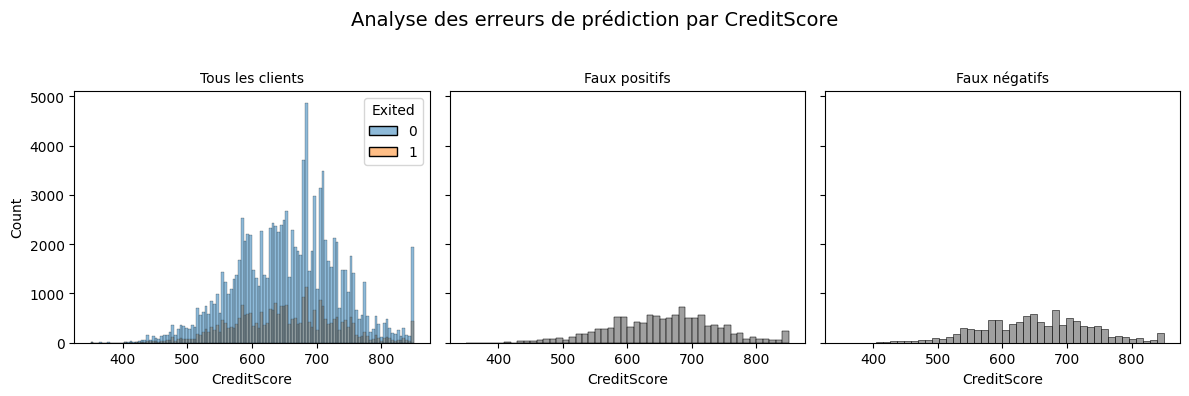

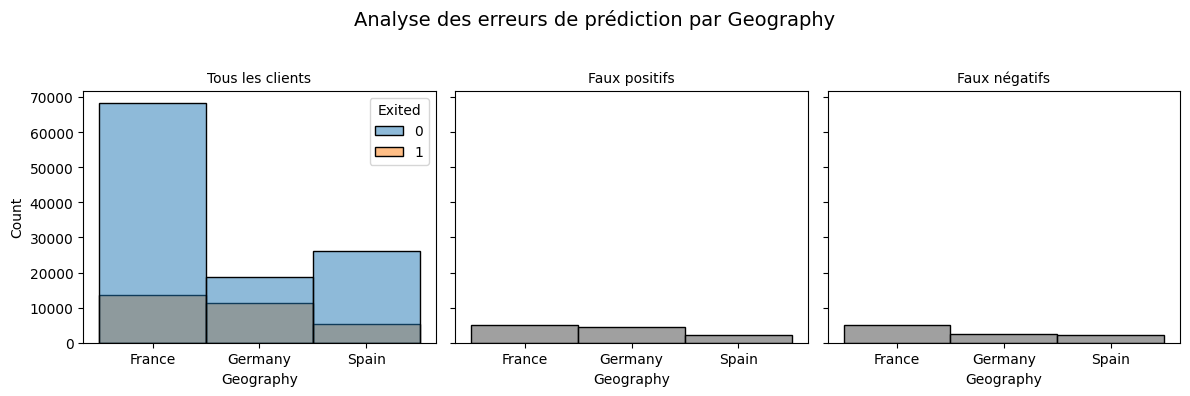

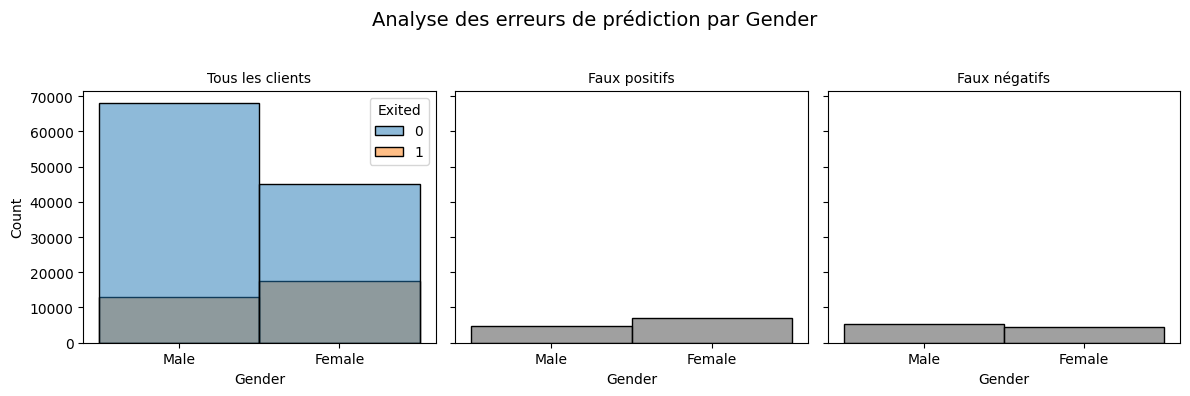

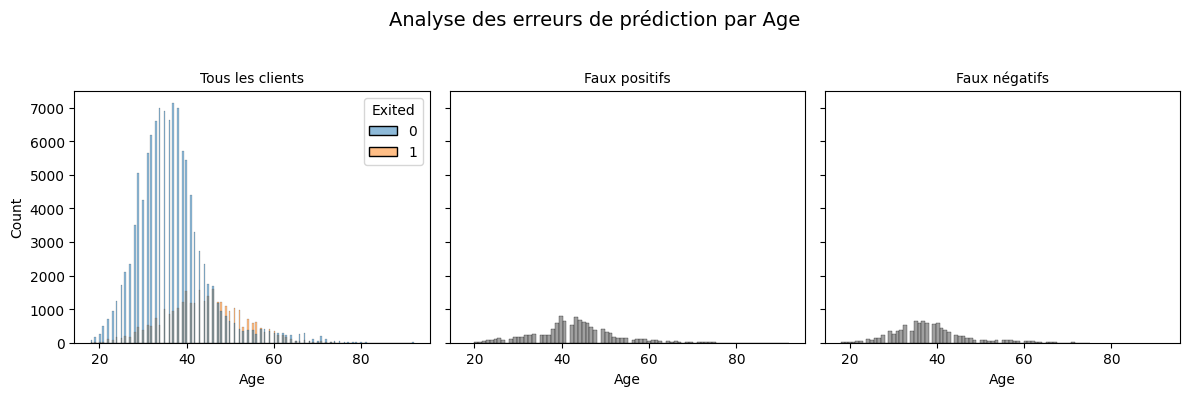

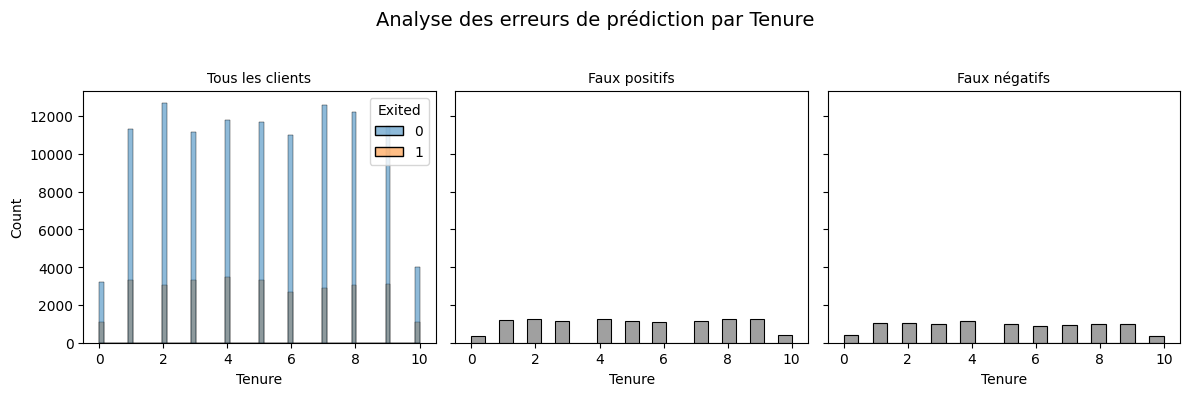

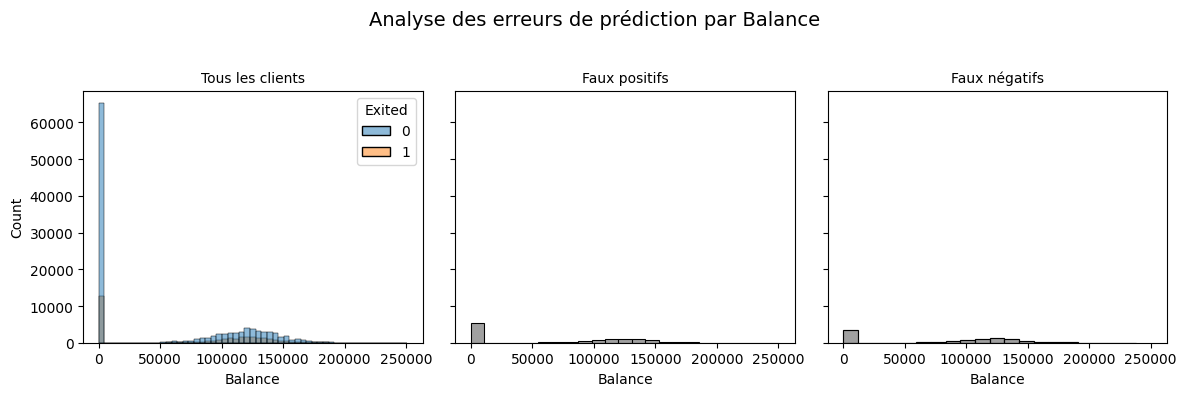

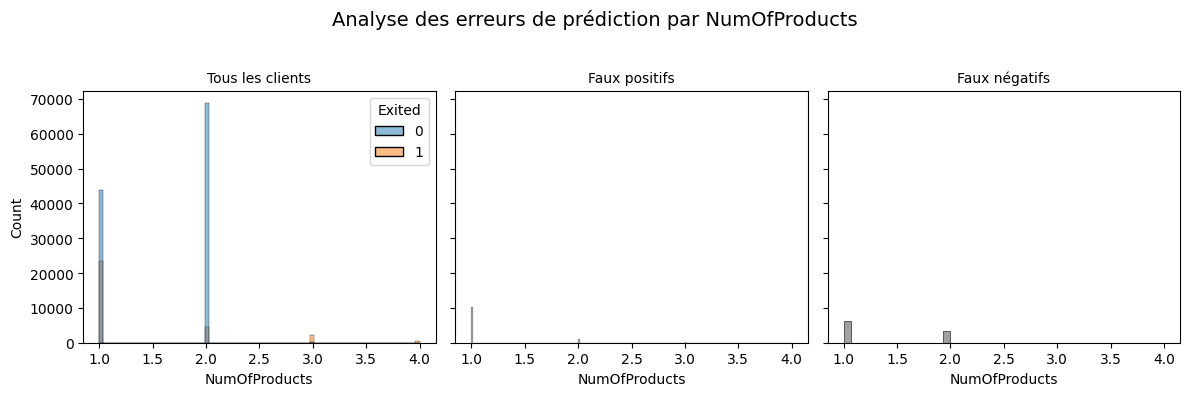

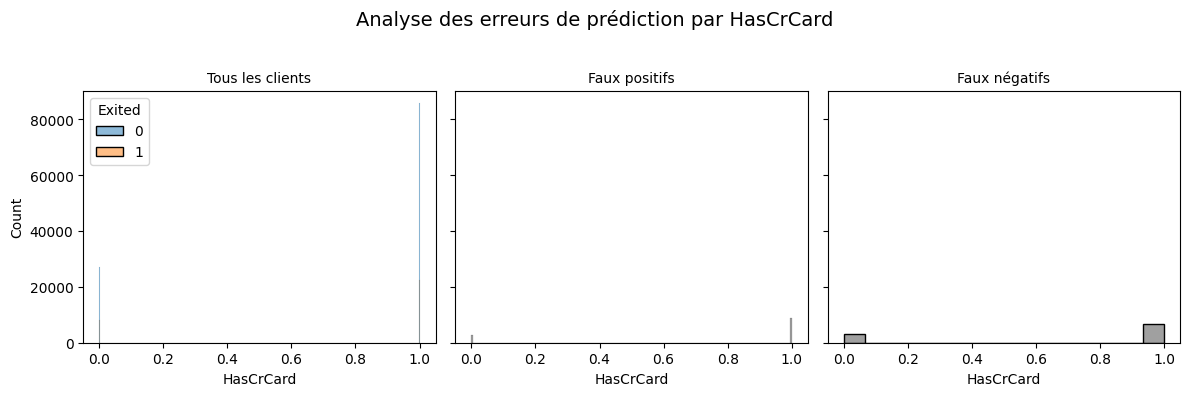

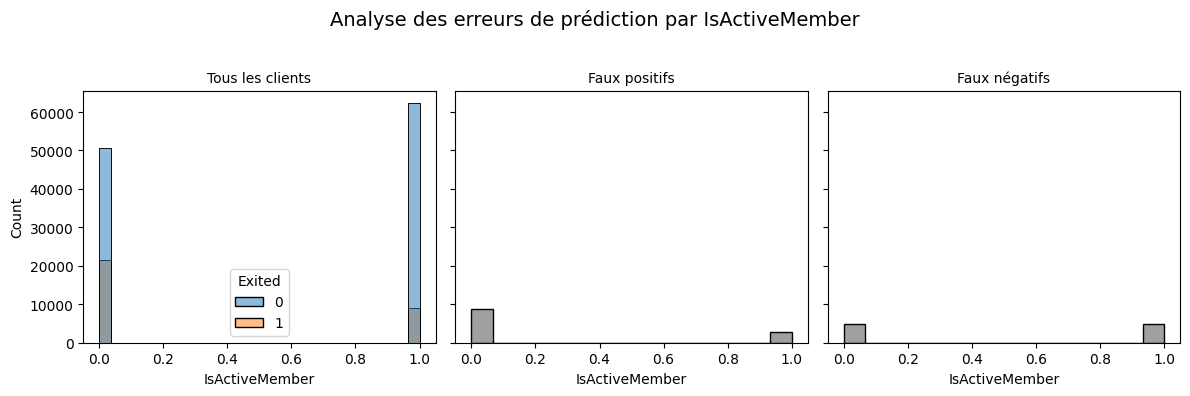

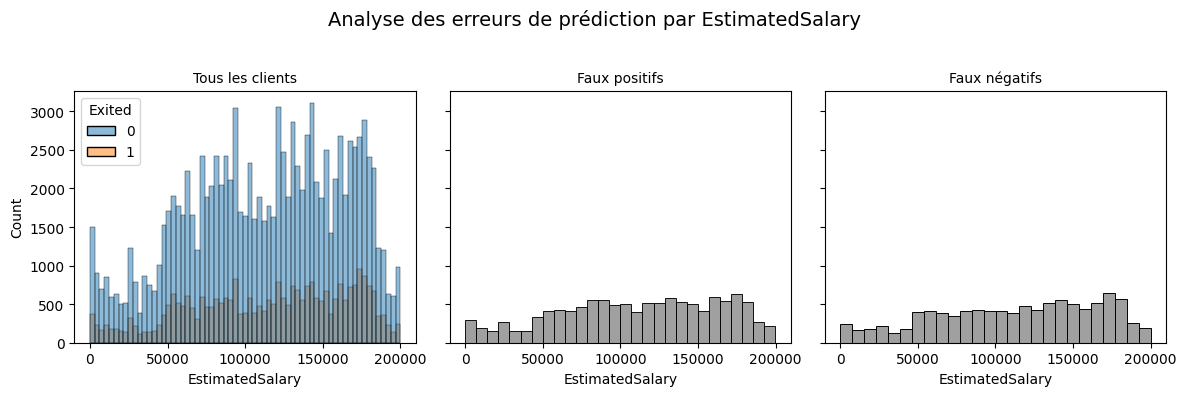

In [9]:
from matplotlib import pyplot as plt
import seaborn as sns

for feature in X.columns:

    # Créer les subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

    # Ajouter un titre général
    fig.suptitle(f"Analyse des erreurs de prédiction par {feature}", fontsize=14)

    # Sous-titre pour chaque subplot
    sns.histplot(X, x=feature, hue=y_true, ax=ax1)
    ax1.set_title("Tous les clients", fontsize=10)

    sns.histplot(X.loc[fp_mask], x=feature, ax=ax2, color='gray')
    ax2.set_title("Faux positifs", fontsize=10)

    sns.histplot(X.loc[fn_mask], x=feature, ax=ax3, color='gray')
    ax3.set_title("Faux négatifs", fontsize=10)

    # Ajuster la mise en page
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Laisser de l'espace pour le titre général
    plt.show()

**observations**: On voit que le chevauchement des classes en fonction de l´ âge est le facteur majeur d´erreur de classification

In [ ]:
X_reduced = X.loc[(X.Age > 30) & (X.Age < 50)]
X_reduced

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

# Créer les subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

# Ajouter un titre général
fig.suptitle("Analyse des erreurs de prédiction par pays et churn-score", fontsize=14)

# Sous-titre pour chaque subplot
sns.histplot(X, x='churn_score', y='Geography', hue=y_true, ax=ax1)
ax1.set_title("Tous les clients", fontsize=10)

sns.histplot(X.loc[fp_mask], x='churn_score', y='Geography', ax=ax2, color='gray')
ax2.set_title("Faux positifs", fontsize=10)

sns.histplot(X.loc[fn_mask], x='churn_score', y='Geography', ax=ax3, color='gray')
ax3.set_title("Faux négatifs", fontsize=10)

# Ajuster la mise en page
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Laisser de l'espace pour le titre général
plt.show()

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

# Créer les subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

# Ajouter un titre général
fig.suptitle("Analyse des erreurs de prédiction par pays et churn-score", fontsize=14)

# Sous-titre pour chaque subplot
sns.scatterplot(X, x='churn_score', y='Age', hue=y_true, ax=ax1)
ax1.set_title("Tous les clients", fontsize=10)

sns.scatterplot(X.loc[fp_mask], x='churn_score', y='Age', ax=ax2, color='gray')
ax2.set_title("Faux positifs", fontsize=10)

sns.scatterplot(X.loc[fn_mask], x='churn_score', y='Age', ax=ax3, color='gray')
ax3.set_title("Faux négatifs", fontsize=10)

# Ajuster la mise en page
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Laisser de l'espace pour le titre général
plt.show()

In [ ]:
# Analyse approfondie des erreurs
# Comparaison des distributions des variables pour les faux positifs et faux négatifs
import seaborn as sns

# Sélectionner les colonnes numériques
numeric_columns = X.select_dtypes(include=['number']).columns

# Créer des visualisations pour chaque variable numérique
for feature in numeric_columns:
    plt.figure(figsize=(10, 5))
    sns.kdeplot(X.loc[fp_mask, feature], label='Faux Positifs', color='red', fill=True, alpha=0.5)
    sns.kdeplot(X.loc[fn_mask, feature], label='Faux Négatifs', color='orange', fill=True, alpha=0.5)
    sns.kdeplot(X.loc[tp_mask, feature], label='Vrais Positifs', color='green', fill=True, alpha=0.5)
    sns.kdeplot(X.loc[tn_mask, feature], label='Vrais Négatifs', color='blue', fill=True, alpha=0.5)
    plt.title(f"Distribution des valeurs pour {feature}")
    plt.xlabel(feature)
    plt.ylabel("Densité")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrer uniquement les colonnes numériques
numeric_columns = X.select_dtypes(include=['number']).columns

# Amélioration de la visualisation avec des histogrammes côte à côte
for feature in numeric_columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True)
    
    # Subplot 1 : Faux positifs et vrais négatifs
    bins = np.linspace(X[feature].min(), X[feature].max(), 30)
    width = (bins[1] - bins[0]) / 2  # Ajuster la largeur des barres pour éviter la superposition
    axes[0].bar(bins[:-1], np.histogram(X.loc[fp_mask, feature], bins=bins)[0], width=width, alpha=0.6, color='red', label='Faux Positifs', align='edge')
    axes[0].bar(bins[:-1] + width, np.histogram(X.loc[tn_mask, feature], bins=bins)[0], width=width, alpha=0.6, color='blue', label='Vrais Négatifs', align='edge')
    axes[0].set_title(f"Faux Positifs vs Vrais Négatifs - {feature}")
    axes[0].set_xlabel(feature)
    axes[0].set_ylabel("Fréquence")
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Subplot 2 : Faux négatifs et vrais positifs
    axes[1].bar(bins[:-1], np.histogram(X.loc[fn_mask, feature], bins=bins)[0], width=width, alpha=0.6, color='orange', label='Faux Négatifs', align='edge')
    axes[1].bar(bins[:-1] + width, np.histogram(X.loc[tp_mask, feature], bins=bins)[0], width=width, alpha=0.6, color='green', label='Vrais Positifs', align='edge')
    axes[1].set_title(f"Faux Négatifs vs Vrais Positifs - {feature}")
    axes[1].set_xlabel(feature)
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    
    # Ajustement de la mise en page
    plt.tight_layout()
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrer uniquement les colonnes numériques
numeric_columns = X.select_dtypes(include=['number']).columns

# Liste des pays
countries = X['Geography'].unique()

# Amélioration de la visualisation avec des histogrammes par pays
for feature in numeric_columns:
    fig, axes = plt.subplots(len(countries), 2, figsize=(14, 3 * len(countries)), sharey=True)  # Réduction de la hauteur des subplots
    
    for i, country in enumerate(countries):
        X_country = X[X['Geography'] == country]
        fp_mask_country = fp_mask & (X['Geography'] == country)
        fn_mask_country = fn_mask & (X['Geography'] == country)
        tp_mask_country = tp_mask & (X['Geography'] == country)
        tn_mask_country = tn_mask & (X['Geography'] == country)
        
        bins = np.linspace(X_country[feature].min(), X_country[feature].max(), 30)
        width = (bins[1] - bins[0]) / 2  # Ajuster la largeur des barres pour éviter la superposition
        
        # Subplot 1 : Faux positifs et vrais négatifs
        axes[i, 0].bar(bins[:-1], np.histogram(X_country.loc[fp_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='red', label='Faux Positifs', align='edge')
        axes[i, 0].bar(bins[:-1] + width, np.histogram(X_country.loc[tn_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='blue', label='Vrais Négatifs', align='edge')
        axes[i, 0].set_title(f"{country} - Faux Positifs vs Vrais Négatifs - {feature}")
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel("Fréquence")
        axes[i, 0].legend()
        axes[i, 0].grid(alpha=0.3)
        
        # Subplot 2 : Faux négatifs et vrais positifs
        axes[i, 1].bar(bins[:-1], np.histogram(X_country.loc[fn_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='orange', label='Faux Négatifs', align='edge')
        axes[i, 1].bar(bins[:-1] + width, np.histogram(X_country.loc[tp_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='green', label='Vrais Positifs', align='edge')
        axes[i, 1].set_title(f"{country} - Faux Négatifs vs Vrais Positifs - {feature}")
        axes[i, 1].set_xlabel(feature)
        axes[i, 1].legend()
        axes[i, 1].grid(alpha=0.3)
    
    # Ajustement de la mise en page
    plt.tight_layout()
    plt.show()

## Analyse des faux négatifs

In [ ]:
X.dtypes

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Filtrer uniquement les colonnes numériques
categorical_columns = X.select_dtypes(include='object').columns

# Liste des pays
countries = X['Geography'].unique()

# Amélioration de la visualisation avec des histogrammes par pays
for feature in categorical_columns:
    fig, axes = plt.subplots(len(countries), 2, figsize=(14, 3 * len(countries)), sharey=True)  # Réduction de la hauteur des subplots
    
    for i, country in enumerate(countries):
        X_country = X[X['Geography'] == country]
        fp_mask_country = fp_mask & (X['Geography'] == country)
        fn_mask_country = fn_mask & (X['Geography'] == country)
        tp_mask_country = tp_mask & (X['Geography'] == country)
        tn_mask_country = tn_mask & (X['Geography'] == country)

        
        
        bins = np.linspace(X_country[feature].min(), X_country[feature].max(), 30)
        width = (bins[1] - bins[0]) / 2  # Ajuster la largeur des barres pour éviter la superposition
        
        # Subplot 1 : Faux positifs et vrais négatifs
        axes[i, 0].bar(bins[:-1], np.histogram(X_country.loc[fp_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='red', label='Faux Positifs', align='edge')
        axes[i, 0].bar(bins[:-1] + width, np.histogram(X_country.loc[tn_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='blue', label='Vrais Négatifs', align='edge')
        axes[i, 0].set_title(f"{country} - Faux Positifs vs Vrais Négatifs - {feature}")
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel("Fréquence")
        axes[i, 0].legend()
        axes[i, 0].grid(alpha=0.3)
        
        # Subplot 2 : Faux négatifs et vrais positifs
        axes[i, 1].bar(bins[:-1], np.histogram(X_country.loc[fn_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='orange', label='Faux Négatifs', align='edge')
        axes[i, 1].bar(bins[:-1] + width, np.histogram(X_country.loc[tp_mask_country, feature], bins=bins)[0], width=width, alpha=0.6, color='green', label='Vrais Positifs', align='edge')
        axes[i, 1].set_title(f"{country} - Faux Négatifs vs Vrais Positifs - {feature}")
        axes[i, 1].set_xlabel(feature)
        axes[i, 1].legend()
        axes[i, 1].grid(alpha=0.3)
    
    # Ajustement de la mise en page
    plt.tight_layout()
    plt.show()

In [ ]:
# Analyse des variables catégoriques
# Comparaison des distributions pour les faux positifs, faux négatifs, vrais positifs et vrais négatifs

# Sélectionner les colonnes catégoriques
categorical_columns = X.select_dtypes(include=['object']).columns

# Créer des visualisations pour chaque variable catégorique
for feature in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=X, x=feature, hue=fp_mask, palette='Reds', label='Faux Positifs', dodge=False, alpha=0.6)
    sns.countplot(data=X, x=feature, hue=fn_mask, palette='Oranges', label='Faux Négatifs', dodge=False, alpha=0.6)
    sns.countplot(data=X, x=feature, hue=tp_mask, palette='Greens', label='Vrais Positifs', dodge=False, alpha=0.6)
    sns.countplot(data=X, x=feature, hue=tn_mask, palette='Blues', label='Vrais Négatifs', dodge=False, alpha=0.6)
    plt.title(f"Distribution des catégories pour {feature}")
    plt.xlabel(feature)
    plt.ylabel("Fréquence")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()